# Import Libraries

In [16]:
import glob
import librosa
import numpy as np

In [2]:
# mean duration of jazz in train dataset
jazz_dataset = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/jazz/*/*.wav")
duration_sum = 0
for audio in jazz_dataset:
    duration_sum += librosa.get_duration(path=audio)
print(f"mean duration (in seconds) of the Jazz genre stems {duration_sum/len(jazz_dataset)}")

mean duration (in seconds) of the Jazz genre stems 30.03297959183698


In [13]:
audio_dataset = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/*/*/*.wav")
noise_dataset = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/*.wav")

unique_sample_rates = set()
for audio in audio_dataset:
    unique_sample_rates.add(librosa.get_samplerate(path=audio))
    
for audio in noise_dataset:
    unique_sample_rates.add(librosa.get_samplerate(path=audio))
    
print(f"Unique sample rates {unique_sample_rates}")

Unique sample rates {44100}


In [33]:
audios = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/*/*/vocals.wav")
max_sum = 0
for audio in audios:
    y, sr = librosa.load(path=audio, sr=None)
    peak = np.max(np.abs(y))
    
    peak_db = librosa.amplitude_to_db(peak)
    max_sum += peak_db
    
print(f"average peak amplitude (in dB) in vocals {max_sum/len(audios)}")

average peak amplitude (in dB) in vocals -12.494920897913865


In [35]:
audios = glob.glob("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/*/*.wav")
mean_sum = 0
for audio in audios:
    y, sr = librosa.load(path=audio, sr=None)

    centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
    track_mean_centroid = np.mean(centroids)
    mean_sum += track_mean_centroid
    
print(f" mean spectral centroid for 'blues' genre {mean_sum/len(audios)}")

 mean spectral centroid for 'blues' genre 2296.7827371150856


In [36]:
genres = ["blues", "classical", "country", "disco", "hiphop","jazz", "metal", "pop", "reggae", "rock"]
genre_and_msc = {}
for genre in genres:
    audios = glob.glob(f"/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/{genre}/*/*.wav")
    mean_sum = 0
    for audio in audios:
        y, sr = librosa.load(path=audio, sr=None)
    
        centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
        track_mean_centroid = np.mean(centroids)
        mean_sum += track_mean_centroid
    genre_and_msc[genre] = mean_sum/len(audios)
    
genre_and_msc

{'blues': np.float64(2296.7827371150856),
 'classical': np.float64(1674.790326156449),
 'country': np.float64(2266.7210020485504),
 'disco': np.float64(2454.1533850826795),
 'hiphop': np.float64(2370.789957346027),
 'jazz': np.float64(2544.114957441355),
 'metal': np.float64(2579.3243146551536),
 'pop': np.float64(2440.884880560034),
 'reggae': np.float64(2404.568992703987),
 'rock': np.float64(2250.0843332686527)}

In [39]:
silence_count = 0
for audio in audio_dataset:
    y, sr  = librosa.load(audio , sr=None) 
    non_silent = librosa.effects.split(y, top_db=20)
    if (non_silent[0][0] != 0) and (non_silent[0][0]/sr > 0.5 ): 
        silence_count+= 1

for audio in noise_dataset:
    y, sr  = librosa.load(audio , sr=None) 
    non_silent = librosa.effects.split(y, top_db=20)
    if (non_silent[0][0] != 0) and (non_silent[0][0]/sr > 0.5 ): 
        silence_count+= 1


In [40]:
silence_count

1043

/tmp/ipykernel_55/2424885090.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]


Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

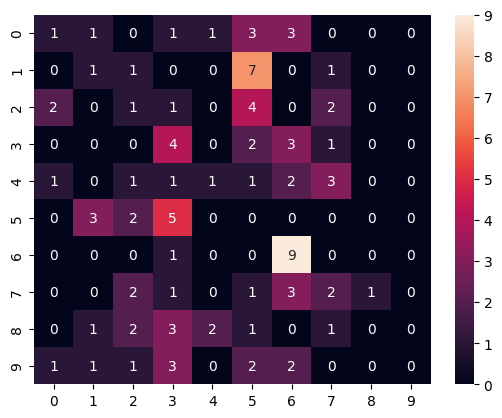

In [43]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average="macro")
cm = confusion_matrix(y_val, y_pred)
cr = classification_report(y_val, y_pred)



print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
sns.heatmap(cm,annot=True)